# Hardware-Assisted Parameterized Circuit Execution (PCE)

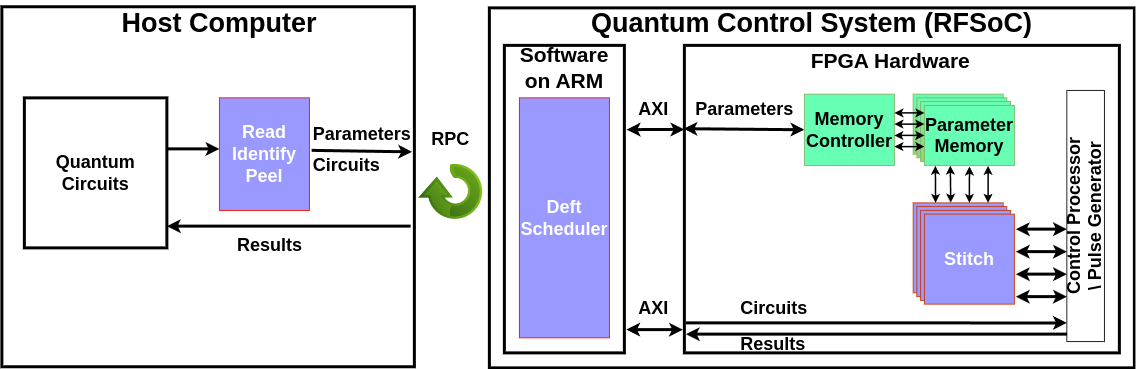

## https://arxiv.org/pdf/2409.03725

Read-Identify-Peel (RIP) automatically detects the structurally equivalency in a batch of circuit, compiles unique circuits, amd peels off the parameters.

Stitch attaches back the peeled parameter in real time in FPGA.

Deft Scheduler orchestrates the circuit execution with the appropriate parameters.

In [ ]:
import qubic.rip as rp #Import RIP for PCE
import pickle

## True-Q Circuits

### Cycle Benchmarking (CB)

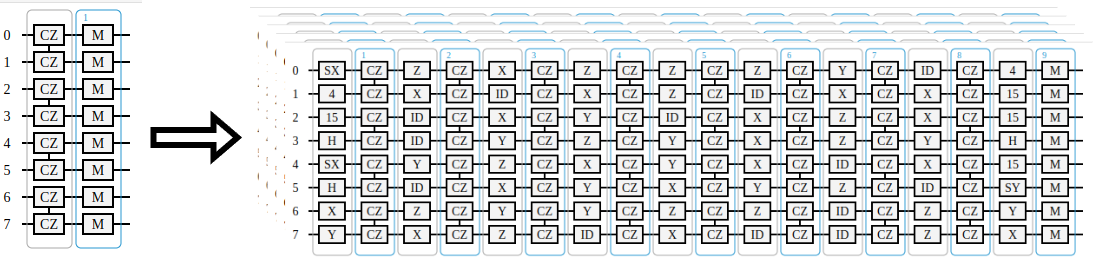

The circuits are generated with TrueQ, compiled using QubiC transpiler, and saved into a file.

To generate the circuit with your own TrueQ, use the code below:

    depth = [8, 64, 256] #Depth
    n_circuits = 30 #Randomization
    qubits = [2, 4, 8] #Qubits    
    
    for qub in qubits:
        circ = {}
        for i in range(0,qub,2):
            circ[(i,i+1)] = tq.Gate.cz #Add two-qubit gate
        tqCirc = tq.Circuit(circ)
    tqCirc.measure_all() #Measure all qubits

### Read the circuit from the file and pass it through the Parameterized Circuit Execution

In [ ]:
#Read circuits from the file
numQubits = 2 #Available option 2, 4, and 8
filename = './circuits/CB'+str(numQubits)+'Qubits'
with open(filename, "rb") as fp:
    cb_qub = pickle.load(fp)

In [ ]:
#Perform PCE and compare with software
phases, parameter_circuits = rp.pce(cb_qub)

### Randomized Benchmarking (RB)

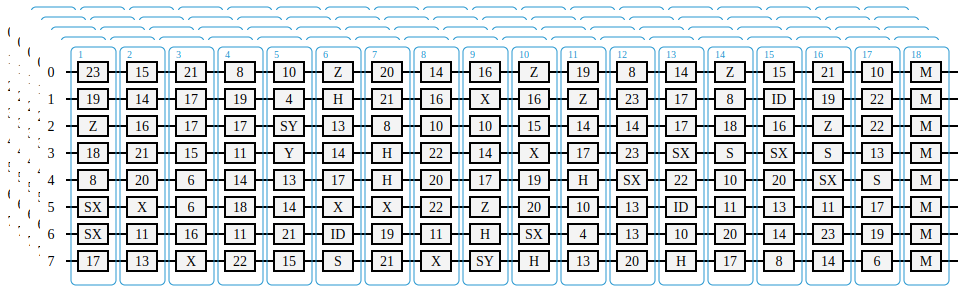

The circuits are generated with TrueQ, compiled using QubiC transpiler, and saved into a file.

To generate the circuit with your own TrueQ, use the code below:

    depth = [16, 128, 512]
    n_circuits = 30
    qubits = [1, 2, 4, 8]

    for qub in qubits:
        print(f'Generating RB for {qub} qubits(s)')
        tqrb = tq.make_srb([i for i in range(0,qub)], depth, n_circuits, compiled_pauli=False)

In [ ]:
#Read circuits from the file
numQubits = 8 #Available option 2, 4, and 8
filename = './circuits/SRB'+str(numQubits)+'Qubits'
with open(filename, "rb") as fp:
    cb_qub = pickle.load(fp)

In [ ]:
#Pass the circuit to PCE function
phases, parameter_circuits = rp.pce(cb_qub)

# Paper 2: QubiCML

## QubiCML - ML-Powered FPGA-based Real-Time Quantum State Discrimination Enabling Mid-circuit Measurements
## https://arxiv.org/pdf/2406.18807

## The below video uses qcal front-end built on top of QubiC to demonstrate QubiCML capabilities